1. Загрузите файл «assc_TRANSACTION.csv». В нем три колонки Customer – ID клиента, Product – покупка, Time – временная метка (для задания не нужна). Определите (написав соответствующий код) сколько различных значений принимают переменные Product и Customer.

Для того, чтобы определить количество уникальных элементов CUSTOMER и PRODUCT необходимо сделать следующее:
Читаем документ, и используем df.nunique()

In [5]:
import pandas as pd
from mlxtend.frequent_patterns import association_rules, fpgrowth
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn_som.som import SOM

df = pd.read_csv("~/Рабочий стол/TRANSACTION.csv")
#print(df.columns)
df = df.drop('TIME', axis=1)
#print(df.columns)
df.nunique() # считает и выводит количество уникальных (различных) значений

CUSTOMER    1001
PRODUCT       20
dtype: int64

Результат: CUSTOMER 1001, PRODUCT 20


2. Найдите частые эпизоды с ограничением на размер правила равным 4, с использованием FPTree и порога на поддержку FPTree, 5%.

In [6]:
# на следующем этапе создаем таблицу: строки - покупатели, столбцы - продукты
# если есть пересечение продукт-покупатель, то ставим 1, иначе 0. Используем функцию lambda x: 1, fill_value=0

df = df.pivot_table(index='CUSTOMER', columns='PRODUCT', aggfunc=lambda x: 1, fill_value=0)
df2 = df.astype(bool)
#print(df2)
frequent_itemsets1 = fpgrowth(df2, min_support=0.05, use_colnames=True)
#print(frequent_itemsets)

# берем только те, которые имеют длину из 4 элементов
frequent_itemsets = frequent_itemsets1[frequent_itemsets1["itemsets"].apply(lambda x: len(x) == 4)]
print(frequent_itemsets["itemsets"])

38        (bourbon, olives, heineken, cracker)
87             (hering, olives, corned_b, ham)
92           (ham, cracker, avocado, heineken)
96          (avocado, ham, heineken, artichok)
97          (ham, cracker, heineken, artichok)
98           (avocado, ham, cracker, artichok)
118              (hering, olives, ham, turkey)
122         (hering, olives, corned_b, turkey)
123            (olives, corned_b, ham, turkey)
124            (hering, corned_b, ham, turkey)
128        (olives, turkey, bourbon, ice_crea)
132           (olives, coke, turkey, ice_crea)
133          (coke, turkey, bourbon, ice_crea)
134            (olives, coke, turkey, bourbon)
145      (hering, baguette, cracker, heineken)
158          (hering, soda, cracker, heineken)
162          (olives, soda, cracker, heineken)
166         (hering, baguette, soda, heineken)
167        (baguette, soda, cracker, heineken)
168          (hering, baguette, soda, cracker)
173           (olives, soda, bourbon, cracker)
174         (

3. Найдите самый большой (где больше всего элементов) частый эпизод, содержащий продукт согласно вашему варианту. Какая у него поддержка?

Продукт: peppers

На основе уже построенного frequent_itemsets, мы берем только те, в которых есть данный продукт. Если частых эпизодов с этим продуктом не существует, напечатаем об этом.
Если они все-таки есть, то отсортируем по длине наборов и выведем самый наибольший.

In [7]:
# Фильтруем наборы, содержащие этот продукт
peppers_sets = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: 'peppers' in x)]

if not peppers_sets.empty:
    peppers_sets = peppers_sets.assign(length=peppers_sets['itemsets'].apply(len))
    peppers_set = peppers_sets.sort_values(by="length", ascending=False).iloc[0]
    print(f"Самый большой частый эпизод: {peppers_set}")
else:
    print("Нет частых наборов.")

Самый большой частый эпизод: support                                 0.093906
itemsets    (chicken, peppers, bourbon, cracker)
length                                         4
Name: 262, dtype: object


4. На основе найденных частых эпизодов постройте ассоциативные правила с порогом на достоверность 30%. Найдите правило с максимальным лифтом, содержащем продукт из вашего варианта в левой части правила. Дайте ему письменную словесную интерпретацию, укажите и объясните его числовые показатели: поддержку, достоверность и подъем.

In [8]:
rules = association_rules(frequent_itemsets1, metric="confidence", min_threshold=0.3)
print(rules)
rules_peppers = rules[rules['antecedents'].apply(lambda x: 'peppers' in x)]
if not rules_peppers.empty:
    max_lift_peppers = rules_peppers.loc[rules_peppers['lift'].idxmax()]
    print("Правило с максимальным лифтом:\n",max_lift_peppers)
else:
    print("Нет частых наборов c peppers.")


              antecedents          consequents  antecedent support  \
0                (hering)           (heineken)            0.485514   
1              (heineken)             (hering)            0.599401   
2                (hering)            (cracker)            0.485514   
3               (cracker)             (hering)            0.487512   
4      (hering, heineken)            (cracker)            0.287712   
...                   ...                  ...                 ...   
1519   (bourbon, cracker)  (chicken, corned_b)            0.239760   
1520  (chicken, baguette)           (heineken)            0.077922   
1521    (hering, chicken)           (heineken)            0.092907   
1522      (chicken, soda)            (cracker)            0.065934   
1523   (chicken, cracker)               (soda)            0.163836   

      consequent support   support  confidence      lift  representativity  \
0               0.599401  0.287712    0.592593  0.988642               1.0   
1  

Поддержка = 0.08991. Это означает, что 8.991% всех транзакций содержат данный частый набор продуктов, включая peppers.

Достоверность = 0.714286. Если покупатель приобретает товары из антецедента правила, то с вероятностью 71.4% он также купит товары из консеквента.

Подъем = 7.526316. Это показывает, что товары в этом правиле встречаются в 7.53 раза чаще, чем если бы они покупались независимо друг от друга. Подъем больше 1 говорит о сильной взаимосвязи между продуктами.

5. Используя только двухместные правила постройте ориентированный граф, где вершины
элементы правила, их цвет (или размер) – поддержка элемента (item support), дуги –
импликации (ориентированы в направлении от условия к следствию), веса дугu –
достоверности.

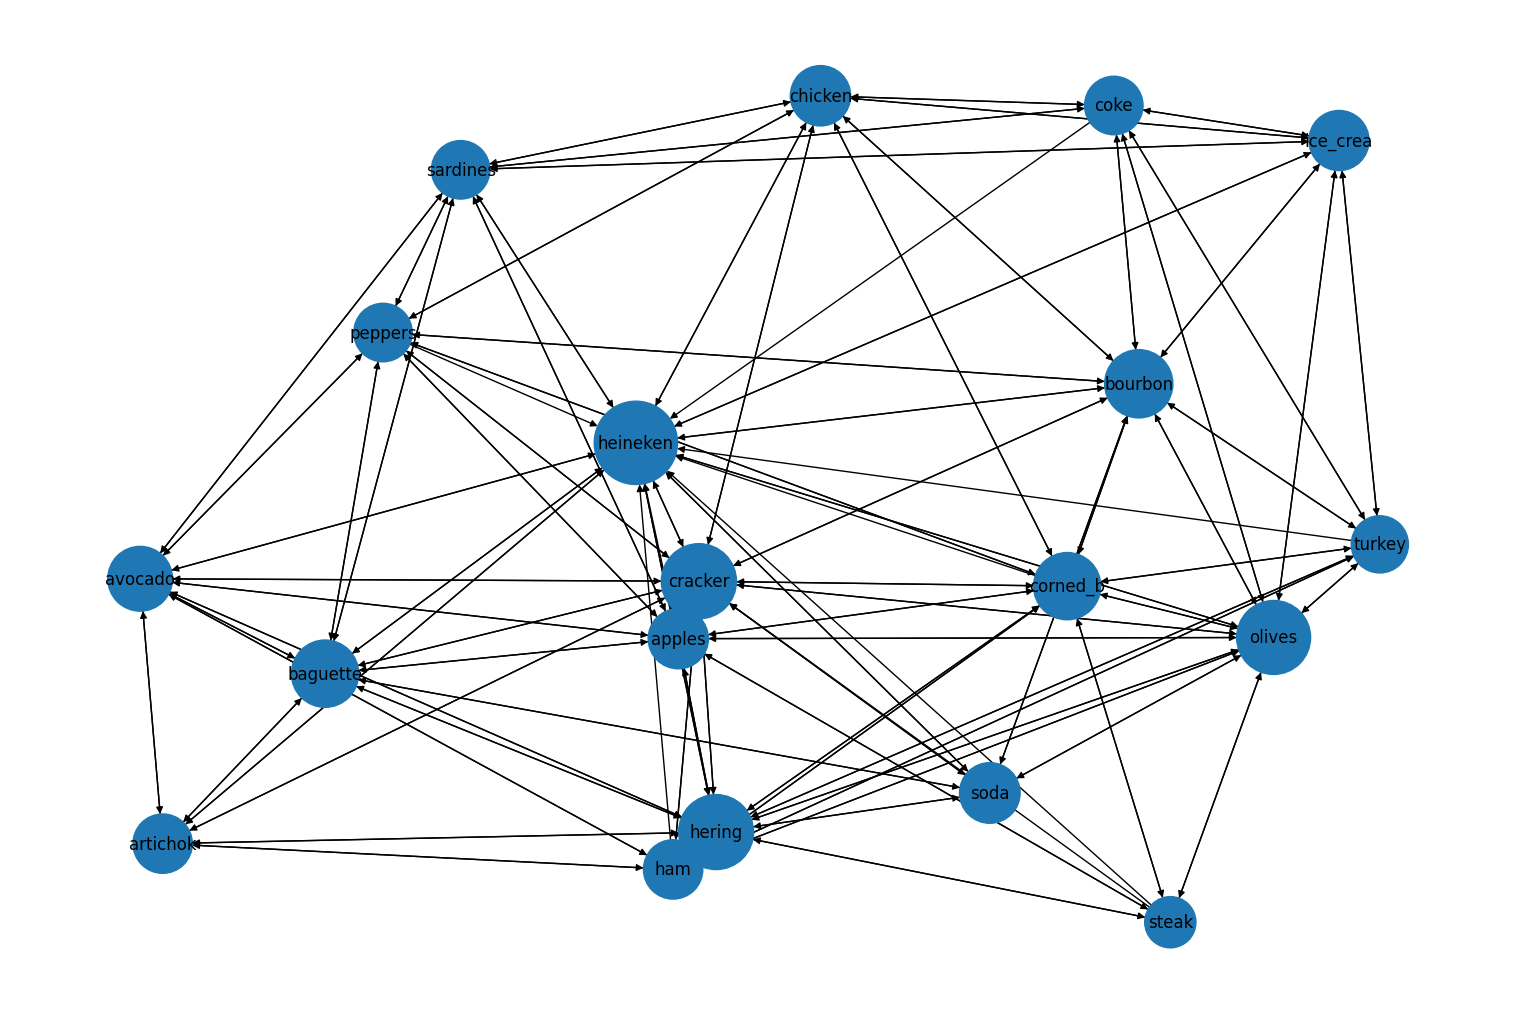

In [9]:
filtered_rules = rules[rules["antecedents"].apply(lambda x: len(x) == 1) & rules["consequents"].apply(lambda x: len(x) == 1)]
#print(filtered_rules)

G = nx.DiGraph()            
for index, row in filtered_rules.iterrows():
    for antecedents in row["antecedents"]:
        for consequents in row["consequents"]:
            G.add_edge(antecedents, consequents, weight = row["confidence"] * 1000)
            
plt.figure(figsize=(15, 10))
node_s = [df2.mean()[node] * 6000 for node in G.nodes]
nx.draw(G, with_labels=True, node_size=node_s)
plt.show()

Комментарий:

Чем больше вершина, тем больше поддержка этого продукта.
Чем длинее дуга, тем больше достоверность.
При этом, дуги ориентированы по следствию.

6. Для данного графа рассчитайте меры центральности согласно вашему варианту и найдите элемент с самой высокой мерой, а также какую меру имеет продукт из вашего варианта.
Clust. coef

In [10]:
clustering_mes = nx.clustering(G)
# По умолчанию функция вычисляет коэффициент для каждого узла в графе и возвращает словарь, 
# где ключи — узлы, а значения — соответствующие им коэффициенты кластеризации
# print(clustering_mes)
max_clustering_element = max(clustering_mes, key=clustering_mes.get)
peppers_clustering_element = clustering_mes["peppers"]
print("Элемент с максимальной мерой центральности:", max_clustering_element)
print("Элемент peppers: ", peppers_clustering_element)

Элемент с максимальной мерой центральности: steak
Элемент peppers:  0.609375


7. Постройте числовую матрицу со счетчиком числа покупок в ячейках, клиентами по строкам и продуктами по столбцам.

In [11]:
matrix_prod = df.copy()
print(matrix_prod)

PRODUCT   apples  artichok  avocado  baguette  bordeaux  bourbon  chicken  \
CUSTOMER                                                                    
0              0         0        0         0         0        1        0   
1              0         0        0         1         0        0        0   
2              0         1        1         0         0        0        0   
3              0         0        0         0         0        1        0   
4              1         0        1         0         0        0        0   
...          ...       ...      ...       ...       ...      ...      ...   
996            0         1        1         0         0        1        1   
997            1         0        0         1         0        0        0   
998            0         0        0         1         0        0        0   
999            0         0        0         0         0        0        1   
1000           1         0        0         0         0        1        0   

8. С помощью метода из вашего варианта постройте линейную проекцию набора данных на
плоскость (2 компоненты) цветом укажите транзакции, содержащие продукт вашего варианта.

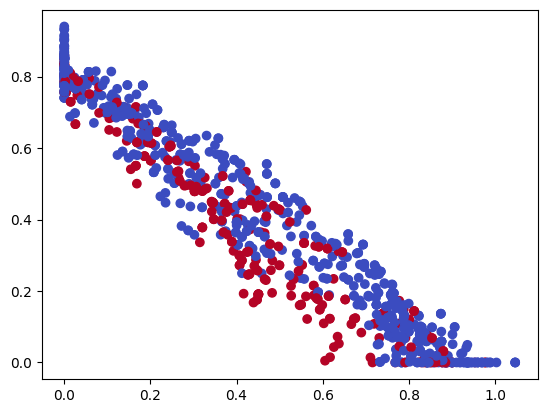

In [12]:
model = NMF(n_components=2, init="random")
nmf_result = model.fit_transform(matrix_prod)
plt.scatter(x=nmf_result[:, 0], y=nmf_result[:, 1], c=matrix_prod['peppers'], cmap='coolwarm')
plt.show()

9.С помощью метода из вашего варианта постройте нелинейную проекцию набора данных на
плоскость цветом укажите транзакции, содержащие продукт из вашего варианта. Не
указанные в задании параметры (например, размер решетки для SOM или число слоев в
автоэнкодере можно выбирать на свое усмотрение для получение наиболее удобной
визуализации). Дайте письменный комментарий, чем с вашей точки зрения для вашего
примера лучше или хуже нелинейная проекция).

SOM

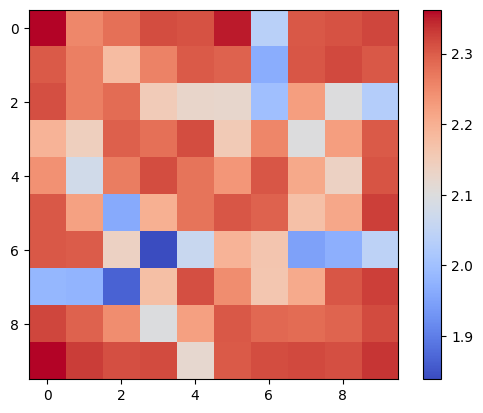

In [17]:
import numpy as np
som = SOM(m=10, n=10, dim=matrix_prod.shape[1])
som.fit(matrix_prod.values, 100)
som_weights = som.weights.reshape(10, 10, -1)
plt.imshow(np.linalg.norm(som_weights, axis=-1), cmap='coolwarm')
plt.colorbar()
plt.show()

10. Из исходной матрицы (из пункта 7) согласно вашему варианту отберите указанное число
независимых переменных с использованием заданного метода.

VarClus, 6

In [19]:
from varclushi import VarClusHi

clusters = VarClusHi(matrix_prod, maxeigval2=1, maxclus=6)
clusters.varclus()
print(clusters.rsquare)
print(clusters.info)

    Cluster  Variable    RS_Own     RS_NC  RS_Ratio
0         0  artichok  0.340953  0.083436  0.719041
1         0   avocado  0.563135  0.093066  0.481695
2         0  baguette  0.331186  0.061182  0.712400
3         0    olives  0.525390  0.114866  0.536201
4         0    turkey  0.274915  0.079463  0.787676
5         0   bourbon  0.309922  0.037706  0.717118
6         1      coke  0.800897  0.088937  0.218539
7         1  ice_crea  0.800897  0.085871  0.217806
8         2    apples  0.386677  0.077819  0.665079
9         2  corned_b  0.463052  0.077625  0.582136
10        2  heineken  0.647073  0.127379  0.404445
11        2     steak  0.338017  0.028491  0.681397
12        3   chicken  0.350307  0.052149  0.685438
13        3       ham  0.203098  0.018494  0.811918
14        3    hering  0.473462  0.141001  0.612968
15        3   peppers  0.342499  0.042892  0.686966
16        3  sardines  0.413083  0.098328  0.650920
17        4      soda  0.705993  0.098617  0.326174
18        4 